# 2. Clustering 1910 CLIP Embeddings via DBSCAN

Inputs:
- 1910_embeddings.npy
- 1910_embeddings.txt (row-aligned with .npy)

Outputs:
- 1910_clusters.json (only cluster_id -> list[str] of .jpg paths)
- 1910_clusters_ordered.json
- 1910_metadata.json

## Setup

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt

## Load filenames and embeddings

In [2]:
# Paths
EMB_NPY = Path("1910_embeddings.npy")
EMB_TXT = Path("1910_embeddings.txt")
PHOTOS_DIR = Path("1910_photos")

print("Using PHOTOS_DIR:", PHOTOS_DIR)

Using PHOTOS_DIR: 1910_photos


In [3]:
filenames_1910 = [ln.strip() for ln in EMB_TXT.read_text(encoding="utf-8").splitlines() if ln.strip()]
print("filenames:", len(filenames_1910))

filenames: 72062


In [4]:
embeddings_1910 = np.load(EMB_NPY)
print("embeddings:", embeddings_1910.shape)

if embeddings_1910.ndim != 2:
    raise ValueError(f"Expected 2D embedding matrix, got shape={embeddings_1910.shape}")

if len(filenames_1910) != embeddings_1910.shape[0]:
    raise ValueError(
        "Row mismatch: filenames and embedding rows must match. "
        f"Got {len(filenames_1910)} filenames vs {embeddings_1910.shape[0]} embedding rows."
    )

print("Alignment check passed.")

embeddings: (72062, 512)
Alignment check passed.


## DBSCAN

In [5]:
eps = 2.4 # epsilon
min_samples = 2

start = time.time()
db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit(embeddings_1910)
end = time.time()
elapsed = end - start
print(f'Time taken: {elapsed:.6f} seconds')

labels = db.labels_

# cluster counts
cluster_ids = sorted([int(c) for c in set(labels) if c != -1])
n_clusters_ = len(cluster_ids)
n_noise_ = int(np.sum(labels == -1))

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Time taken: 32.445531 seconds
Estimated number of clusters: 2321
Estimated number of noise points: 65941


## Build 1910_cluster.json

In [6]:
# Build clusters.json as: cluster_id -> list of "relative/path.jpg"
clusters = {}  # str(cluster_id) -> list[str]

for i, lab in enumerate(labels):
    lab = int(lab)
    if lab == -1:
        continue

    stem = Path(filenames_1910[i]).stem  # preserves folder structure if present in the txt
    rel_jpg = f"{stem}.jpg"

    clusters.setdefault(str(lab), []).append(rel_jpg)

## Cluster sizes + order

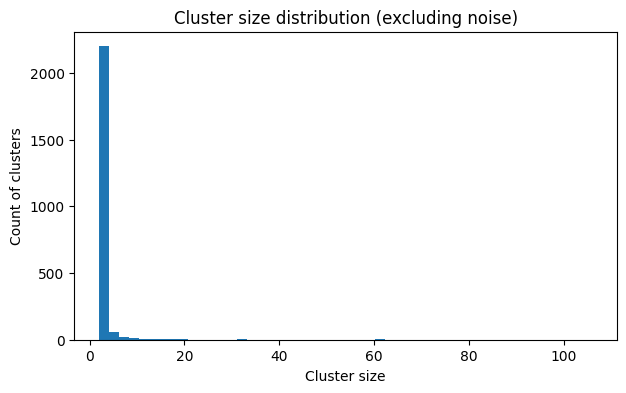

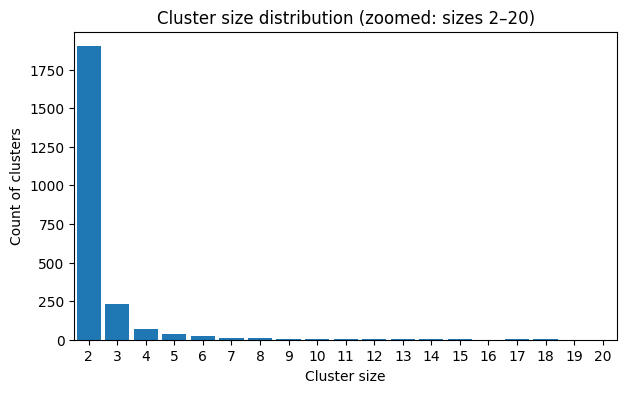

Size of cluster 84: 106
Size of cluster 88: 62
Size of cluster 4: 62
Size of cluster 39: 57
Size of cluster 125: 41
Size of cluster 89: 32
Size of cluster 90: 32
Size of cluster 94: 32
Size of cluster 134: 28
Size of cluster 561: 21
Size of cluster 193: 20
Size of cluster 589: 19
Size of cluster 247: 18
Size of cluster 167: 18
Size of cluster 213: 17
Size of cluster 712: 17
Size of cluster 356: 15
Size of cluster 124: 15
Size of cluster 162: 14
Size of cluster 105: 14
Size of cluster 135: 14
Size of cluster 774: 14
Size of cluster 305: 14
Size of cluster 730: 13
Size of cluster 631: 13
Size of cluster 307: 13
Size of cluster 1694: 12
Size of cluster 106: 12
Size of cluster 327: 11
Size of cluster 704: 11
Size of cluster 541: 11
Size of cluster 80: 10
Size of cluster 333: 10
Size of cluster 538: 10
Size of cluster 266: 10
Size of cluster 473: 10
Size of cluster 111: 10
Size of cluster 706: 9
Size of cluster 437: 9
Size of cluster 650: 9
Size of cluster 57: 9
Size of cluster 182: 9
Size 

In [7]:
sizes = pd.Series({cid: len(v) for cid, v in clusters.items()}).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.hist(sizes.values, bins=50)
plt.title("Cluster size distribution (excluding noise)")
plt.xlabel("Cluster size")
plt.ylabel("Count of clusters")
plt.show()

# Zoomed: cluster sizes 2–20, unit bins
zoom_sizes = sizes.values[(sizes.values >= 2) & (sizes.values <= 20)]
plt.figure(figsize=(7, 4))
plt.hist(zoom_sizes, bins=np.arange(2, 22), align="left", rwidth=0.85)
plt.title("Cluster size distribution (zoomed: sizes 2–20)")
plt.xlabel("Cluster size")
plt.ylabel("Count of clusters")
plt.xticks(np.arange(2, 21))
plt.xlim(1.5, 20.5)
plt.show()

# Print cluster sizes in descending order
for cid, sz in sizes.items():
    print(f"Size of cluster {cid}: {sz}")

## Save 1910_clusters.json

In [8]:
# Save clusters JSON (clusters only)
with open("1910_clusters.json", "w", encoding="utf-8") as fp:
    json.dump(clusters, fp, ensure_ascii=False, indent=2)

print("Saved: 1910_clusters.json")

Saved: 1910_clusters.json


In [9]:
# reorder clusters dict by descending cluster size
clusters_ordered = {cid: clusters[cid] for cid in sizes.index}

with open("1910_clusters_ordered.json", "w", encoding="utf-8") as fp:
    json.dump(clusters_ordered, fp, ensure_ascii=False, indent=2)

print("Saved: 1910_clusters_ordered.json")

Saved: 1910_clusters_ordered.json


## Metadata

In [10]:
OUT_META = Path("1910_metadata.json")

metadata = {
    "dataset": "1910 images",
    "n_images": int(len(filenames_1910)),
    "embedding_dim": int(embeddings_1910.shape[1]),
    "embedding_files": {
        "embeddings_npy": str(EMB_NPY),
        "filenames_txt": str(EMB_TXT),
    },
    "photos_dir_used": str(PHOTOS_DIR),

    "clustering": {
        "algorithm": "DBSCAN",
        "params": {
            "eps": float(eps),
            "min_samples": int(min_samples)
        },
        "n_clusters_excluding_noise": int(n_clusters_),
        "n_noise_points": int(n_noise_),
        "cluster_labels_start_at": 0,
        "noise_label": -1,
        "runtime_seconds": float(elapsed),
    },

    "outputs": {
        "clusters_json": "1910_clusters.json",
        "ordered_clusters_json": "1910_clusters_ordered.json"
    }
}

with open(OUT_META, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved: 1910_metadata.json")

Saved: 1910_metadata.json
